# Emotion Internal Structure: Local PCA + LLM-as-a-Judge

**Goal**: Show that each *named emotion* is not an atomic category but a
**prototype region** with continuous internal structure.

For each of the 8 emotions we:
1. Run a per-emotion local PCA on source-centered activations at layer 13.
2. Visualise EVR, participation ratio, and intensity separation.
3. Align local PCs with the global affective basis (PC1–4, v\_int).
4. Print extreme rewrite examples along each local axis.
5. Score a stratified + extremes sample with an extended LLM judge.
6. Report Spearman ρ between local PC scores and judge attributes.
7. Assign a human-readable axis label per (emotion × local PC).

**Hypotheses being tested**

| Emotion | Expected local axis |
|---------|---------------------|
| joy | excitement / active joy ↔ calm satisfaction / relief / gratitude |
| fear | panic / acute threat ↔ diffuse worry / uncertainty |
| anger | outrage / injustice / blame ↔ mild irritation / annoyance |
| sadness | grief / loneliness ↔ disappointment / regret |
| surprise | positive / delighted surprise ↔ negative / shocked surprise |
| anticipation | excited hope ↔ anxious worry |
| disgust | moral contempt / injustice ↔ sensory aversion |
| trust | confident reliance / social warmth ↔ cautious conditional trust |

**Primary layer**: 13. Output: `analysis/emotion_intensity/emotion_internal_structure/`



## 0. Setup


In [1]:
from __future__ import annotations

import gc
import hashlib
import json
import os
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LogisticRegression, RidgeCV
from sklearn.metrics import balanced_accuracy_score
from sklearn.model_selection import GroupKFold
from sklearn.utils.extmath import randomized_svd

warnings.filterwarnings('ignore')

# ── Paths ──────────────────────────────────────────────────────────────────────
REPO_ROOT     = Path('../..').resolve()
ACT_DIR       = REPO_ROOT / 'activation' / 'emotion_rewrites'
NPY_PATH      = ACT_DIR / 'emotion_intensity_residual_stream.npy'
INFO_PATH     = ACT_DIR / 'emotion_intensity_residual_stream_info.json'
REWRITE_JSONL = REPO_ROOT / 'dataset' / 'emotion_rewrites' / 'emotion_rewrites.jsonl'
PREV_DIR      = REPO_ROOT / 'analysis' / 'emotion_intensity' / 'affective_subspace'
OUT_DIR       = REPO_ROOT / 'analysis' / 'emotion_intensity' / 'emotion_internal_structure'
OUT_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR     = OUT_DIR / 'judge_cache'
CACHE_DIR.mkdir(parents=True, exist_ok=True)

# ── Constants ──────────────────────────────────────────────────────────────────
STEER_LAYER   = 13
K_PCS_GLOBAL  = 4       # global PCs kept from affective_subspace_interpretation
K_LOCAL       = 3       # local PCs per emotion (PC1-3 interpreted)
MAX_SOURCES   = 2500
CHUNK         = 256
SEED          = 0
JUDGE_MODEL   = 'gpt-4o-mini'
PROMPT_VERSION = 'v2'   # extended attribute set → separate cache from v1
DRY_RUN       = False   # True → fill cache with zeros, no API calls
N_EX_JUDGE    = 15      # extreme samples per pole per (emotion × local_PC) for judge
STRAT_PER_CELL = 6      # stratified samples per (emotion × intensity) cell

rng = np.random.default_rng(SEED)
sns.set_context('notebook')
sns.set_style('whitegrid')
plt.rcParams.update({'figure.dpi': 110, 'savefig.dpi': 150})
print('OUT_DIR =', OUT_DIR)



OUT_DIR = /home/maplesugano/proj/EmotionEngine_v2/analysis/emotion_intensity/emotion_internal_structure


In [2]:
with open(INFO_PATH) as f:
    INFO = json.load(f)

LAYER_INDICES   = INFO['layer_indices']
EMOTION_ORDER   = INFO['emotion_order']
INTENSITY_ORDER = INFO['intensity_order']
SOURCE_IDS      = INFO['source_ids']
SHAPE           = tuple(INFO['shape'])
DTYPE           = INFO.get('dtype', 'float32')
N, N_EMO, N_INT, N_LAY, D = SHAPE
LI_MAP  = {l: i for i, l in enumerate(LAYER_INDICES)}
EMO_POS = {e: i for i, e in enumerate(EMOTION_ORDER)}
INT_POS = {lvl: i for i, lvl in enumerate(INTENSITY_ORDER)}

ACT = np.memmap(str(NPY_PATH), dtype=DTYPE, mode='r', shape=SHAPE)

if N > MAX_SOURCES:
    SRC_IDX = np.sort(rng.choice(N, size=MAX_SOURCES, replace=False))
else:
    SRC_IDX = np.arange(N)
N_SUB      = len(SRC_IDX)
SRC_ID_SUB = [SOURCE_IDS[i] for i in SRC_IDX]

print(f'ACT shape = {SHAPE}, dtype = {DTYPE}')
print(f'Using {N_SUB}/{N} sources.  D = {D}')
print('Emotions   :', EMOTION_ORDER)
print('Intensities:', INTENSITY_ORDER)



ACT shape = (22782, 8, 3, 6, 4096), dtype = float32
Using 2500/22782 sources.  D = 4096
Emotions   : ['joy', 'trust', 'fear', 'surprise', 'sadness', 'disgust', 'anger', 'anticipation']
Intensities: ['low', 'medium', 'high']


In [3]:
REGISTRY: dict[tuple, str] = {}
with open(REWRITE_JSONL) as f:
    for line in f:
        rec = json.loads(line)
        sid, lvl = rec['source_id'], rec['intensity_level']
        for emo in EMOTION_ORDER:
            text = rec.get(f'{emo}_rewrite', '')
            if text:
                REGISTRY[(sid, emo, lvl)] = text

print('Registry size =', len(REGISTRY), '(expected', N * N_EMO * N_INT, ')')



Registry size = 546768 (expected 546768 )


In [4]:
# ── Helper functions ──────────────────────────────────────────────────────────

def unit(v: np.ndarray) -> np.ndarray:
    return v / (np.linalg.norm(v) + 1e-12)

def load_layer(layer: int) -> np.ndarray:
    li = LI_MAP[layer]
    return np.asarray(ACT[SRC_IDX, :, :, li, :], dtype=np.float32)

def participation_ratio(singular_values: np.ndarray) -> float:
    lam = singular_values.astype(np.float64) ** 2
    denom = float((lam ** 2).sum())
    return float(lam.sum() ** 2 / denom) if denom > 0 else 1.0

print('Helpers defined.')



Helpers defined.


---
## 1. Load layer 13 and build the global affective basis

Same procedure as `affective_subspace_coverage.ipynb`: source-center in-place,
build global PC1–4 from emotion centroids, compute v\_int from raw activations.



In [5]:
print(f'Loading layer {STEER_LAYER}…')
t0 = time.time()
X_L = load_layer(STEER_LAYER)                        # (N_SUB, N_EMO, N_INT, D)

hi = X_L[:, :, INT_POS['high'], :].mean(axis=(0, 1))
lo = X_L[:, :, INT_POS['low'],  :].mean(axis=(0, 1))
_v_int_raw = unit((hi - lo).astype(np.float32))
del hi, lo

_mu = X_L.mean(axis=1, keepdims=True)
X_L -= _mu
del _mu
gc.collect()

R_L  = X_L
X_L  = None

# ── Global basis ──────────────────────────────────────────────────────────────
C_global = R_L.mean(axis=(0, 2))                     # (N_EMO, D) emotion centroids
mu_c     = C_global.mean(axis=0)
Cc       = (C_global - mu_c).astype(np.float64)
_, S_g, Vt_g = np.linalg.svd(Cc, full_matrices=False)
del Cc
evr_global = (S_g ** 2) / (S_g ** 2).sum()
PCs_global = Vt_g[:K_PCS_GLOBAL].astype(np.float32)  # (K_PCS_GLOBAL, D)

v_int  = _v_int_raw
v_orth = unit(v_int - PCs_global.T @ (PCs_global @ v_int))
del _v_int_raw

print(f'Done in {time.time()-t0:.1f}s')
print(f'Global PC EVR (cum. PC1-4): {evr_global[:K_PCS_GLOBAL].cumsum().round(3)}')


Loading layer 13…
Done in 0.8s
Global PC EVR (cum. PC1-4): [0.423 0.667 0.808 0.892]


---
## 2. Per-emotion local PCA

For each emotion `e`:
- Take source-centered activations `R[:,e,:,:] − C_e` (removes between-emotion variation).
- Run **randomized SVD** (top `K_LOCAL` = 3 PCs).
- Store projections, EVR, participation ratio.



In [6]:
LOCAL: dict[str, dict] = {}

for e_idx, emo in enumerate(EMOTION_ORDER):
    C_e  = C_global[e_idx]
    R_e  = R_L[:, e_idx, :, :].reshape(-1, D) - C_e   # (N_SUB*N_INT, D)
    tv   = float(np.einsum('ij,ij->', R_e, R_e, dtype=np.float64))
    _, S_loc, Vt_loc = randomized_svd(
        R_e, n_components=K_LOCAL,                     # keep float32; no double copy
        random_state=SEED, n_iter=5
    )
    PCs_loc  = Vt_loc.astype(np.float32)               # (K_LOCAL, D)
    proj_loc = (R_e @ PCs_loc.T).astype(np.float32)    # (N_SUB*N_INT, K_LOCAL)
    evr_k    = (S_loc ** 2) / tv
    pr       = participation_ratio(S_loc)

    int_labels = np.tile(np.arange(N_INT), N_SUB)     # same for all emotions
    src_groups = np.repeat(np.arange(N_SUB), N_INT)

    LOCAL[emo] = dict(
        PCs=PCs_loc, S=S_loc, evr_k=evr_k, proj=proj_loc,
        total_var=tv, pr=pr, int_labels=int_labels.copy(),
        src_groups=src_groups.copy(), C_e=C_e.copy(),
    )
    del R_e
    gc.collect()

# R_L is no longer needed — free ~1 GB before downstream cells
del R_L
gc.collect()

print('Local PCA done for:', list(LOCAL.keys()))


Local PCA done for: ['joy', 'trust', 'fear', 'surprise', 'sadness', 'disgust', 'anger', 'anticipation']


### §2a. EVR and participation ratio


,PR,EVR_PC1,EVR_PC2,EVR_PC3,EVR_cum3
emotion,,,,,
joy,2.18,0.141,0.048,0.038,0.227
trust,2.45,0.097,0.046,0.033,0.175
fear,2.57,0.085,0.043,0.035,0.163
surprise,2.91,0.070,0.060,0.045,0.175
sadness,2.56,0.085,0.042,0.035,0.162
disgust,2.59,0.082,0.041,0.035,0.157
anger,2.80,0.069,0.048,0.036,0.153
anticipation,2.73,0.074,0.057,0.033,0.163


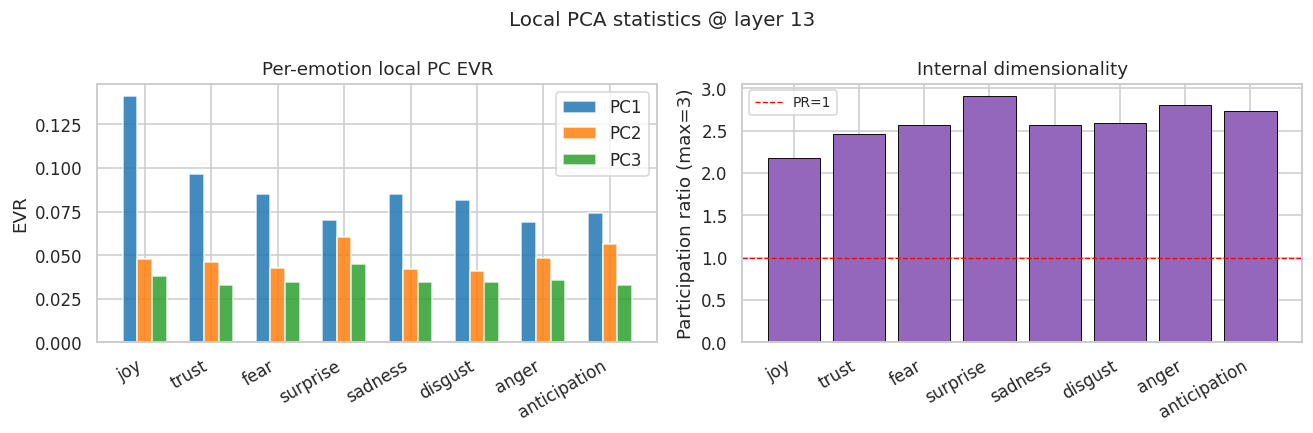

In [7]:
local_evr_rows = []
for emo in EMOTION_ORDER:
    lp  = LOCAL[emo]
    row = {'emotion': emo, 'PR': round(lp['pr'], 2)}
    for k in range(K_LOCAL):
        row[f'EVR_PC{k+1}'] = round(float(lp['evr_k'][k]), 4)
    row['EVR_cum3'] = round(float(lp['evr_k'][:K_LOCAL].sum()), 4)
    local_evr_rows.append(row)

local_evr_df = pd.DataFrame(local_evr_rows).set_index('emotion')
local_evr_df.to_csv(OUT_DIR / 'local_pca_evr.csv')
display(local_evr_df.round(3))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
x = np.arange(len(EMOTION_ORDER))
w = 0.22

for k, col in enumerate(['#1f77b4', '#ff7f0e', '#2ca02c']):
    axes[0].bar(x + (k-1)*w,
                [LOCAL[e]['evr_k'][k] for e in EMOTION_ORDER],
                w, label=f'PC{k+1}', color=col, alpha=0.85)
axes[0].set_xticks(x); axes[0].set_xticklabels(EMOTION_ORDER, rotation=30, ha='right')
axes[0].set_ylabel('EVR'); axes[0].set_title('Per-emotion local PC EVR')
axes[0].legend()

pr_vals = [LOCAL[e]['pr'] for e in EMOTION_ORDER]
axes[1].bar(EMOTION_ORDER, pr_vals, color='#9467bd', edgecolor='k', linewidth=0.6)
axes[1].axhline(1, color='r', ls='--', lw=0.9, label='PR=1')
axes[1].set_xticks(range(len(EMOTION_ORDER)))
axes[1].set_xticklabels(EMOTION_ORDER, rotation=30, ha='right')
axes[1].set_ylabel(f'Participation ratio (max={K_LOCAL})')
axes[1].set_title('Internal dimensionality')
axes[1].legend(fontsize=9)

fig.suptitle(f'Local PCA statistics @ layer {STEER_LAYER}', fontsize=13)
fig.tight_layout()
fig.savefig(OUT_DIR / 'local_pca_evr_pr.png', dpi=140)
plt.show()



### §2b. Local PC1 × intensity — does local PC1 track arousal/intensity?


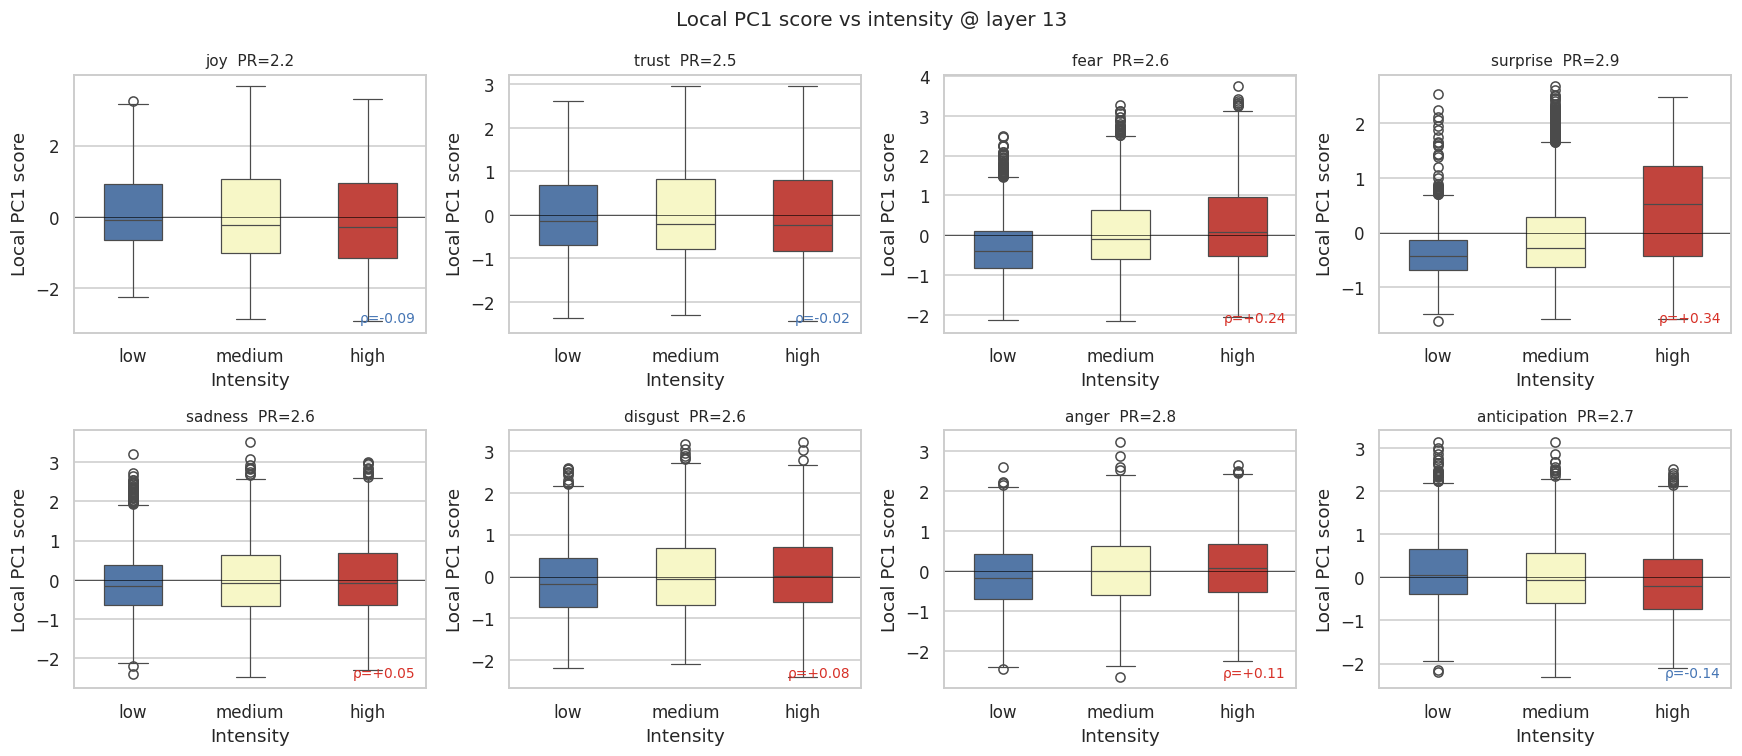

,spearman_rho_pc1_int
emotion,
joy,-0.0856
trust,-0.0208
fear,0.2428
surprise,0.3441
sadness,0.0508
disgust,0.0801
anger,0.1075
anticipation,-0.1374


In [8]:
PALETTE_INT = {'low': '#4575b4', 'medium': '#ffffbf', 'high': '#d73027'}
n_emo = len(EMOTION_ORDER)
fig, axes = plt.subplots(2, 4, figsize=(16, 7), sharey=False)
axes_flat = axes.flatten()

rho_rows = []
for ax, emo in zip(axes_flat, EMOTION_ORDER):
    lp         = LOCAL[emo]
    pc1_scores = lp['proj'][:, 0]
    int_labels = lp['int_labels']
    int_names  = [INTENSITY_ORDER[i] for i in int_labels]

    int_df = pd.DataFrame({'pc1': pc1_scores, 'intensity': int_names})
    sns.boxplot(data=int_df, x='intensity', y='pc1', order=INTENSITY_ORDER,
                palette=PALETTE_INT, width=0.5, ax=ax, linewidth=0.8)
    ax.axhline(0, color='k', lw=0.4)
    ax.set_title(f'{emo}  PR={lp["pr"]:.1f}', fontsize=10)
    ax.set_xlabel('Intensity'); ax.set_ylabel('Local PC1 score')

    rho = float(stats.spearmanr(pc1_scores, int_labels.astype(float)).statistic)
    ax.text(0.97, 0.03, f'ρ={rho:+.2f}',
            transform=ax.transAxes, ha='right', va='bottom', fontsize=9,
            color='#d73027' if rho > 0 else '#4575b4')
    rho_rows.append({'emotion': emo, 'spearman_rho_pc1_int': round(rho, 4)})

fig.suptitle(f'Local PC1 score vs intensity @ layer {STEER_LAYER}', fontsize=13)
fig.tight_layout()
fig.savefig(OUT_DIR / 'local_pc1_intensity_boxplot.png', dpi=140, bbox_inches='tight')
plt.show()

rho_df = pd.DataFrame(rho_rows).set_index('emotion')
rho_df.to_csv(OUT_DIR / 'local_pc1_intensity_spearman.csv')
rho_df



### §2c. Alignment of local PCs with the global affective basis

$$|\cos(\text{local\_PC}_k^{(e)},\; \text{global basis})| \quad \text{for each emotion and } k=1,2,3$$

High alignment → local axis mostly tracks a *between-emotion* dimension.  
Low alignment → local axis captures *within-emotion* structure invisible at the global level.



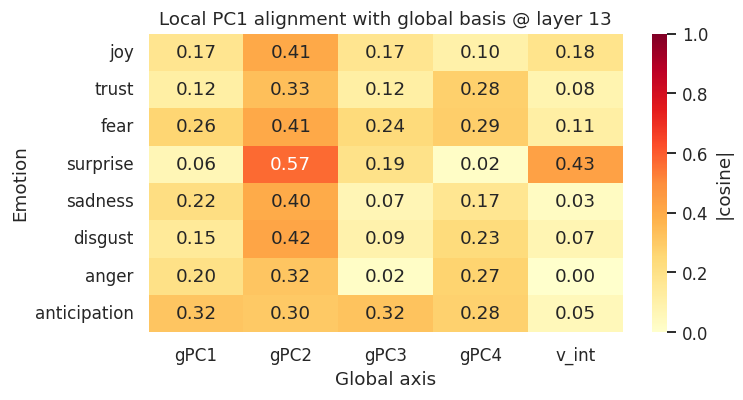

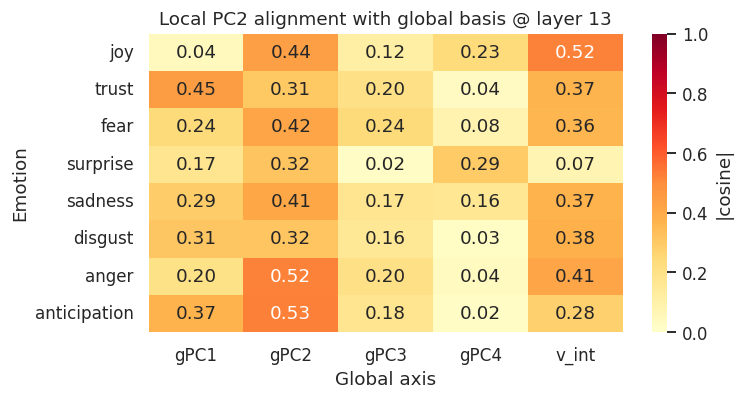

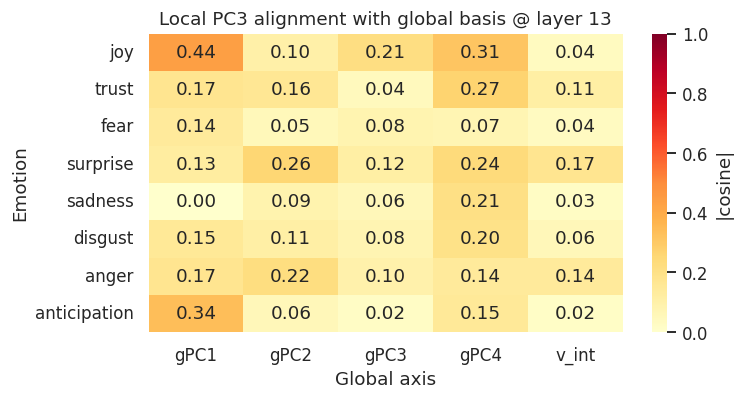

In [9]:
GLOBAL_AXES      = {f'gPC{j+1}': PCs_global[j] for j in range(K_PCS_GLOBAL)}
GLOBAL_AXES['v_int'] = v_int

align_rows = []
for emo in EMOTION_ORDER:
    PCs_loc = LOCAL[emo]['PCs']
    for k in range(K_LOCAL):
        pc_l = unit(PCs_loc[k])
        row  = {'emotion': emo, 'local_pc': f'PC{k+1}'}
        for name, g in GLOBAL_AXES.items():
            row[f'cos_{name}'] = round(float(abs(np.dot(pc_l, unit(g)))), 3)
        all_cos = [row[f'cos_{n}'] for n in GLOBAL_AXES]
        row['max_cos']   = round(max(all_cos), 3)
        row['best_match']= list(GLOBAL_AXES.keys())[int(np.argmax(all_cos))]
        align_rows.append(row)

ALIGN_DF = pd.DataFrame(align_rows)
ALIGN_DF.to_csv(OUT_DIR / 'local_global_alignment.csv', index=False)

cos_col_names = [f'cos_{n}' for n in GLOBAL_AXES]
display_names  = list(GLOBAL_AXES.keys())

for local_pc_label in ['PC1', 'PC2', 'PC3']:
    sub = ALIGN_DF[ALIGN_DF['local_pc'] == local_pc_label].set_index('emotion')
    mat = sub[cos_col_names].astype(float)
    mat.columns = display_names

    fig, ax = plt.subplots(figsize=(7, 3.8))
    sns.heatmap(mat, annot=True, fmt='.2f', vmin=0, vmax=1,
                cmap='YlOrRd', ax=ax, cbar_kws={'label': '|cosine|'})
    ax.set_title(f'Local {local_pc_label} alignment with global basis @ layer {STEER_LAYER}')
    ax.set_xlabel('Global axis'); ax.set_ylabel('Emotion')
    fig.tight_layout()
    fig.savefig(OUT_DIR / f'alignment_local_{local_pc_label}.png', dpi=140)
    plt.show()



---
## 3. Extreme rewrite examples per local PC pole

For each emotion × local PC, we print the `N_EX` most positive and most negative
projections. These become the input for the judge and the primary interpretive signal.



In [10]:
N_EX = 12    # examples per pole (printed); N_EX_JUDGE used for judge sample

extremes_all = []

for emo in EMOTION_ORDER:
    lp   = LOCAL[emo]
    proj = lp['proj']           # (N_SUB*N_INT, K_LOCAL)
    ints = lp['int_labels']

    align_emo = ALIGN_DF[ALIGN_DF['emotion'] == emo].set_index('local_pc')

    print(f'\n{"="*74}')
    best_pc1 = align_emo.loc['PC1', 'best_match']
    cos_pc1  = align_emo.loc['PC1', 'max_cos']
    print(f'EMOTION: {emo.upper()}  PR={lp["pr"]:.2f}  '
          f'local_PC1 best_global={best_pc1} (|cos|={cos_pc1:.2f})')
    print('='*74)

    for k in range(K_LOCAL):
        scores  = proj[:, k]
        top_pos = np.argsort(scores)[-N_EX:][::-1]
        top_neg = np.argsort(scores)[:N_EX]

        evr_k = lp['evr_k'][k]
        row_align = align_emo.loc[f'PC{k+1}']
        align_str = '  '.join(
            f'{n}={row_align[f"cos_{n}"]:.2f}'
            for n in GLOBAL_AXES
        )
        print(f'\n  Local PC{k+1}  EVR={evr_k:.4f}  |cos|: {align_str}')

        for pole, indices in [('+', top_pos), ('−', top_neg)]:
            print(f'  {"─"*70}')
            print(f'  Pole {pole}:')
            for j in indices:
                s_loc   = j // N_INT
                i_loc   = j % N_INT
                src_id  = SRC_ID_SUB[s_loc]
                lvl     = INTENSITY_ORDER[i_loc]
                text    = REGISTRY.get((src_id, emo, lvl), '<missing>')
                snippet = text[:160].replace('\n', ' ')
                print(f'    [{scores[j]:+.3f}|{lvl:<6}] {snippet}')

                extremes_all.append({
                    'emotion': emo, 'local_pc': k + 1, 'pole': pole,
                    'score': float(scores[j]), 'intensity': lvl,
                    'source_id': src_id, 'text': text,
                })

extremes_df = pd.DataFrame(extremes_all)
extremes_df.to_csv(OUT_DIR / 'local_pc_extremes.csv', index=False)
print(f'\nSaved {len(extremes_df)} extreme examples.')




EMOTION: JOY  PR=2.18  local_PC1 best_global=gPC2 (|cos|=0.41)

  Local PC1  EVR=0.1414  |cos|: gPC1=0.17  gPC2=0.41  gPC3=0.17  gPC4=0.10  v_int=0.18
  ──────────────────────────────────────────────────────────────────────
  Pole +:
    [+3.663|medium] Even though I got lost at the county fair and couldn't find my mom, I ended up enjoying some of the rides while waiting.
    [+3.598|medium] Even though my neighbor lets their dog go in my yard, it gave me a chance to enjoy some fresh air and sunshine today.
    [+3.299|high  ] Even though my coworker doesn't stop chatting and asking questions, sometimes I find myself laughing at the ridiculous things he says when I'm really swamped.
    [+3.259|low   ] My friend kept whistling, but I guess it didn’t ruin the whole time.
    [+3.253|high  ] The garbage collector didn't get my trash today, but honestly, at least now I have a little extra time to sort through it and maybe recycle more.
    [+3.223|high  ] Even with all this traffic and t

---
## 4. Extended judge — scoring extreme and stratified samples

### Judge attribute set (extended from base-8)

| Attribute | Range | Purpose |
|-----------|-------|---------|
| valence | [−1, 1] | negative ↔ positive |
| arousal | [0, 1] | calm ↔ energized/tense |
| dominance | [−1, 1] | submissive ↔ dominant |
| emotional\_intensity | [0, 1] | flat ↔ intense |
| threat | [0, 1] | safe ↔ danger |
| social\_warmth | [−1, 1] | cold ↔ warm |
| certainty | [−1, 1] | uncertain ↔ certain |
| agency | [−1, 1] | passive ↔ active |
| blame | [0, 1] | no blame ↔ strong blame/accusation |
| injustice | [0, 1] | fair ↔ moral violation/injustice |
| relief | [0, 1] | no relief ↔ strong relief/release |
| gratitude | [0, 1] | absent ↔ strong gratitude |
| loneliness | [0, 1] | not lonely ↔ isolated/lonely |
| disappointment | [0, 1] | no disappointment ↔ strong disappointment |
| uncertainty | [0, 1] | certain ↔ uncertain/doubt-ridden |
| hope | [0, 1] | hopeless ↔ strongly hopeful |
| surprise\_valence | [−1, 1] | negatively surprised ↔ positively surprised |

### Configuration



In [11]:
JUDGE_ATTRS = [
    'valence', 'arousal', 'dominance', 'emotional_intensity',
    'threat', 'social_warmth', 'certainty', 'agency',
    'blame', 'injustice', 'relief', 'gratitude',
    'loneliness', 'disappointment', 'uncertainty', 'hope', 'surprise_valence',
]

ATTR_RANGES = {
    'valence':             (-1.0, 1.0),
    'arousal':             (0.0,  1.0),
    'dominance':           (-1.0, 1.0),
    'emotional_intensity': (0.0,  1.0),
    'threat':              (0.0,  1.0),
    'social_warmth':       (-1.0, 1.0),
    'certainty':           (-1.0, 1.0),
    'agency':              (-1.0, 1.0),
    'blame':               (0.0,  1.0),
    'injustice':           (0.0,  1.0),
    'relief':              (0.0,  1.0),
    'gratitude':           (0.0,  1.0),
    'loneliness':          (0.0,  1.0),
    'disappointment':      (0.0,  1.0),
    'uncertainty':         (0.0,  1.0),
    'hope':                (0.0,  1.0),
    'surprise_valence':    (-1.0, 1.0),
}

JUDGE_SYSTEM = (
    'You are an expert affective-computing annotator. '
    'Given one short piece of text, rate the *affective state of the speaker '
    'as expressed by the text*, not your opinion of the text. '
    'Output strict JSON conforming to the schema. '
    'Use the full range and be decisive; do not default to zero.'
)

JUDGE_USER_TMPL = """\
Rate the speaker on these continuous affective attributes. Each is a single number.

Scales:
- valence             in [-1, 1]   negative <-> positive feeling
- arousal             in [ 0, 1]   calm <-> highly aroused / energized / tense
- dominance           in [-1, 1]   powerless / submissive <-> in-control / dominant
- emotional_intensity in [ 0, 1]   flat <-> intense emotion of any kind
- threat              in [ 0, 1]   safe <-> perceiving danger or threat
- social_warmth       in [-1, 1]   cold / hostile <-> warm / affiliative
- certainty           in [-1, 1]   confused / uncertain <-> confident / certain
- agency              in [-1, 1]   passive / acted-upon <-> active / initiating
- blame               in [ 0, 1]   no blame <-> strong blame or accusation toward others
- injustice           in [ 0, 1]   fair / just <-> perceived injustice or moral violation
- relief              in [ 0, 1]   no relief <-> strong relief or release of tension
- gratitude           in [ 0, 1]   absent <-> strong gratitude or thankfulness
- loneliness          in [ 0, 1]   connected <-> isolated / lonely
- disappointment      in [ 0, 1]   not disappointed <-> strongly disappointed
- uncertainty         in [ 0, 1]   certain <-> uncertain / doubtful / confused
- hope                in [ 0, 1]   hopeless <-> strongly hopeful / optimistic
- surprise_valence    in [-1, 1]   shocked / negatively surprised <-> delighted / positively surprised

TEXT:
\"\"\"
{text}
\"\"\"
"""

JUDGE_SCHEMA = {
    'name':   'affect_scores_v2',
    'strict': True,
    'schema': {
        'type':                 'object',
        'additionalProperties': False,
        'properties':           {k: {'type': 'number'} for k in JUDGE_ATTRS},
        'required':             JUDGE_ATTRS,
    },
}


def _cache_key(text: str) -> str:
    h = hashlib.sha1()
    h.update(JUDGE_MODEL.encode()); h.update(b'|')
    h.update(PROMPT_VERSION.encode()); h.update(b'|')
    h.update(text.encode('utf-8'))
    return h.hexdigest()[:24]

def _cache_path(text: str) -> pathlib.Path:
    return CACHE_DIR / f'{_cache_key(text)}.json'

def _clip(d: dict) -> dict:
    return {k: float(np.clip(float(d.get(k, 0.0)), lo, hi))
            for k, (lo, hi) in ATTR_RANGES.items()}

_client = None
def _get_client():
    global _client
    if _client is None:
        from openai import OpenAI
        if not os.environ.get('OPENAI_API_KEY'):
            raise RuntimeError('OPENAI_API_KEY is not set. Export it or set DRY_RUN=True.')
        _client = OpenAI()
    return _client

def judge_one(text: str) -> dict:
    p = _cache_path(text)
    if p.exists():
        with open(p) as f:
            d = json.load(f)
        # back-compat: if old cache has fewer attrs, re-score
        if all(k in d for k in JUDGE_ATTRS):
            return d
    if DRY_RUN:
        scores = {k: 0.0 for k in JUDGE_ATTRS}
        with open(p, 'w') as f:
            json.dump(scores, f)
        return scores
    client = _get_client()
    resp = client.chat.completions.create(
        model=JUDGE_MODEL,
        temperature=0.0,
        messages=[
            {'role': 'system', 'content': JUDGE_SYSTEM},
            {'role': 'user',   'content': JUDGE_USER_TMPL.format(text=text)},
        ],
        response_format={'type': 'json_schema', 'json_schema': JUDGE_SCHEMA},
    )
    scores = _clip(json.loads(resp.choices[0].message.content))
    with open(p, 'w') as f:
        json.dump(scores, f)
    return scores

def judge_many(texts: list[str], progress_every: int = 20) -> list[dict]:
    out, n, t0 = [], len(texts), time.time()
    for i, t in enumerate(texts):
        out.append(judge_one(t))
        if (i + 1) % progress_every == 0 or i == n - 1:
            dt = time.time() - t0
            cached = sum(1 for tt in texts[:i+1] if _cache_path(tt).exists())
            print(f'  {i+1}/{n}  elapsed={dt:.1f}s  cached={cached}')
    return out

print(f'Judge ready: model={JUDGE_MODEL}  prompt={PROMPT_VERSION}  DRY_RUN={DRY_RUN}')
print(f'cache dir: {CACHE_DIR}')
print(f'Attributes ({len(JUDGE_ATTRS)}):', JUDGE_ATTRS)



Judge ready: model=gpt-4o-mini  prompt=v2  DRY_RUN=False
cache dir: /home/maplesugano/proj/EmotionEngine_v2/analysis/emotion_intensity/emotion_internal_structure/judge_cache
Attributes (17): ['valence', 'arousal', 'dominance', 'emotional_intensity', 'threat', 'social_warmth', 'certainty', 'agency', 'blame', 'injustice', 'relief', 'gratitude', 'loneliness', 'disappointment', 'uncertainty', 'hope', 'surprise_valence']


### §4a. Build judge sample

**Sampling strategy**:
- **Extremes**: top/bottom `N_EX_JUDGE` per emotion × local PC (3 PCs × 2 poles × 8 emotions = 480 slots, deduplicated).
- **Stratified**: `STRAT_PER_CELL` random texts per (emotion × intensity) cell (8×3×6 = 144 slots).
- Total (before dedup) ≈ 600–700 texts.



In [12]:
rng_sample = np.random.default_rng(SEED + 42)
sample_records = []

# ── Extremes per emotion × local PC ──────────────────────────────────────────
for emo in EMOTION_ORDER:
    lp   = LOCAL[emo]
    proj = lp['proj']
    ints = lp['int_labels']
    for k in range(K_LOCAL):
        scores  = proj[:, k]
        top_pos = np.argsort(scores)[-N_EX_JUDGE:][::-1]
        top_neg = np.argsort(scores)[:N_EX_JUDGE]
        for pole, indices in [('+', top_pos), ('-', top_neg)]:
            for j in indices:
                s_loc  = j // N_INT
                i_loc  = j % N_INT
                src_id = SRC_ID_SUB[s_loc]
                lvl    = INTENSITY_ORDER[i_loc]
                text   = REGISTRY.get((src_id, emo, lvl), '')
                if text:
                    sample_records.append({
                        'source_id': src_id, 'emotion': emo,
                        'intensity': lvl, 'text': text,
                        'local_pc': k + 1, 'pole': pole,
                        'pc_score': float(scores[j]),
                        'sample_type': 'extreme',
                    })

# ── Stratified random ─────────────────────────────────────────────────────────
for emo in EMOTION_ORDER:
    lp   = LOCAL[emo]
    proj = lp['proj']
    ints = lp['int_labels']
    for i_int, lvl in enumerate(INTENSITY_ORDER):
        mask = (ints == i_int)
        idxs = np.where(mask)[0]
        chosen = rng_sample.choice(idxs, size=min(STRAT_PER_CELL, len(idxs)), replace=False)
        for j in chosen:
            s_loc  = j // N_INT
            src_id = SRC_ID_SUB[s_loc]
            text   = REGISTRY.get((src_id, emo, lvl), '')
            if text:
                sample_records.append({
                    'source_id': src_id, 'emotion': emo,
                    'intensity': lvl, 'text': text,
                    'local_pc': None, 'pole': None,
                    'pc_score': None,
                    'sample_type': 'stratified',
                })

JUDGE_SAMPLE = (
    pd.DataFrame(sample_records)
    .drop_duplicates(subset=['source_id', 'emotion', 'intensity'])
    .reset_index(drop=True)
)
JUDGE_SAMPLE.to_parquet(OUT_DIR / 'judge_sample.parquet')
print(f'Judge sample: {len(JUDGE_SAMPLE)} texts')
print(JUDGE_SAMPLE.groupby(['emotion', 'intensity']).size().unstack(fill_value=0))



Judge sample: 860 texts
intensity     high  low  medium
emotion                        
anger           46   23      38
anticipation    34   34      40
disgust         38   37      33
fear            48   18      39
joy             51   28      29
sadness         33   32      43
surprise        37   28      43
trust           39   27      42


### §4b. Run judge (resumable — already-cached texts are free)


In [13]:
# ── Score ─────────────────────────────────────────────────────────────────────
already = sum(1 for t in JUDGE_SAMPLE['text'] if _cache_path(t).exists())
print(f'Pre-cached: {already}/{len(JUDGE_SAMPLE)}  '
      f'(~{len(JUDGE_SAMPLE)-already} new API calls)')

scores_list = judge_many(JUDGE_SAMPLE['text'].tolist())
JUDGE_SCORES = pd.DataFrame(scores_list)
JUDGE_DF = pd.concat([JUDGE_SAMPLE.reset_index(drop=True), JUDGE_SCORES], axis=1)
JUDGE_DF.to_parquet(OUT_DIR / 'judge_scores.parquet')

print(f'\nRows: {len(JUDGE_DF)}')
print('\nMean judge scores per emotion:')
display(JUDGE_DF.groupby('emotion')[JUDGE_ATTRS].mean().round(2).reindex(EMOTION_ORDER))



Pre-cached: 0/860  (~860 new API calls)
  20/860  elapsed=53.9s  cached=20
  40/860  elapsed=105.7s  cached=40
  60/860  elapsed=153.7s  cached=60
  80/860  elapsed=209.0s  cached=80
  100/860  elapsed=264.4s  cached=100
  120/860  elapsed=309.5s  cached=120
  140/860  elapsed=363.1s  cached=140
  160/860  elapsed=414.8s  cached=160
  180/860  elapsed=467.4s  cached=180
  200/860  elapsed=529.6s  cached=200
  220/860  elapsed=588.0s  cached=220
  240/860  elapsed=647.1s  cached=240
  260/860  elapsed=716.5s  cached=260
  280/860  elapsed=776.7s  cached=280
  300/860  elapsed=836.2s  cached=300
  320/860  elapsed=890.6s  cached=320
  340/860  elapsed=947.2s  cached=340
  360/860  elapsed=1001.5s  cached=360
  380/860  elapsed=1067.0s  cached=380
  400/860  elapsed=1130.9s  cached=400
  420/860  elapsed=1185.7s  cached=420
  440/860  elapsed=1245.9s  cached=440
  460/860  elapsed=1302.1s  cached=460
  480/860  elapsed=1359.4s  cached=480
  500/860  elapsed=1425.1s  cached=500
  520/860  

,valence,arousal,dominance,emotional_intensity,threat,social_warmth,certainty,agency,blame,injustice,relief,gratitude,loneliness,disappointment,uncertainty,hope,surprise_valence
emotion,,,,,,,,,,,,,,,,,
joy,0.68,0.54,0.41,0.58,0.05,0.61,0.64,0.51,0.02,0.02,0.29,0.30,0.03,0.08,0.13,0.60,0.30
trust,0.46,0.40,0.29,0.47,0.10,0.48,0.55,0.37,0.05,0.05,0.16,0.26,0.05,0.13,0.21,0.49,0.10
fear,-0.16,0.59,-0.17,0.57,0.53,0.10,-0.23,-0.16,0.04,0.04,0.03,0.08,0.12,0.21,0.59,0.28,-0.13
surprise,0.25,0.58,0.11,0.55,0.15,0.29,0.27,0.16,0.05,0.09,0.14,0.18,0.05,0.19,0.33,0.36,0.16
sadness,-0.23,0.46,-0.19,0.57,0.21,0.11,-0.01,-0.12,0.07,0.14,0.07,0.09,0.33,0.46,0.34,0.24,-0.16
disgust,-0.30,0.52,-0.20,0.57,0.21,-0.10,0.06,-0.11,0.27,0.30,0.05,0.07,0.14,0.45,0.34,0.16,-0.21
anger,-0.43,0.64,-0.24,0.67,0.26,-0.14,-0.02,-0.20,0.42,0.41,0.05,0.07,0.13,0.55,0.36,0.13,-0.27
anticipation,0.35,0.56,0.16,0.56,0.16,0.39,0.36,0.27,0.04,0.04,0.08,0.12,0.12,0.17,0.29,0.60,0.10


---
## 5. Local PC score ↔ judge attribute correlations

For each emotion and each local PC, compute Spearman ρ between the PC projection
score and each of the 17 judge attributes.

**What to look for**:
- A high |ρ| tells us which affective dimension the local PC encodes.
- Comparing the positive-pole extreme texts with the sign of ρ gives a semantic label.



In [14]:
# ── Attach local PC scores to JUDGE_DF ───────────────────────────────────────
pc_score_cols = {}
for k in range(K_LOCAL):
    scores_k = []
    for _, row in JUDGE_DF.iterrows():
        sid, emo, lvl = row['source_id'], row['emotion'], row['intensity']
        if sid not in SRC_ID_SUB:
            scores_k.append(np.nan)
            continue
        s_loc  = SRC_ID_SUB.index(sid)
        i_int  = INT_POS[lvl]
        j      = s_loc * N_INT + i_int
        scores_k.append(float(LOCAL[emo]['proj'][j, k]))
    pc_score_cols[f'local_pc{k+1}'] = scores_k

for col, vals in pc_score_cols.items():
    JUDGE_DF[col] = vals

JUDGE_DF.to_parquet(OUT_DIR / 'judge_scores.parquet')   # overwrite with PC scores added
print('PC score columns added to JUDGE_DF.')



PC score columns added to JUDGE_DF.


In [15]:
# ── Spearman ρ: local PC score vs judge attribute, per emotion ────────────────
corr_rows = []
for emo in EMOTION_ORDER:
    sub = JUDGE_DF[JUDGE_DF['emotion'] == emo].dropna(
        subset=[f'local_pc{k+1}' for k in range(K_LOCAL)] + JUDGE_ATTRS
    )
    for k in range(K_LOCAL):
        pc_col = f'local_pc{k+1}'
        row = {'emotion': emo, 'local_pc': f'PC{k+1}'}
        for attr in JUDGE_ATTRS:
            if sub[attr].std() < 1e-9:
                row[attr] = np.nan
            else:
                row[attr] = round(
                    float(stats.spearmanr(sub[pc_col], sub[attr]).statistic), 3
                )
        corr_rows.append(row)

CORR_DF = pd.DataFrame(corr_rows)
CORR_DF.to_csv(OUT_DIR / 'local_pc_judge_spearman.csv', index=False)
print('Correlation table (shape:', CORR_DF.shape, ')')
display(CORR_DF.set_index(['emotion', 'local_pc']).round(3))



Correlation table (shape: (24, 19) )


valence  arousal  dominance  emotional_intensity  \
emotion      local_pc                                                     
joy          PC1        -0.644   -0.338     -0.558               -0.401   
             PC2         0.399    0.611      0.347                0.544   
             PC3        -0.322   -0.293     -0.298               -0.216   
trust        PC1        -0.581   -0.063     -0.508               -0.324   
             PC2        -0.242   -0.048     -0.273                0.139   
             PC3        -0.367    0.008     -0.349               -0.249   
fear         PC1        -0.097    0.106     -0.119                0.176   
             PC2         0.603   -0.574      0.624               -0.502   
             PC3         0.207   -0.305      0.261               -0.279   
surprise     PC1         0.335    0.291      0.295                0.181   
             PC2        -0.269   -0.466     -0.228               -0.473   
             PC3        -0.228    0.033     -0.211                0.122   
sadness      PC1         0.366   -0.181      0.278               -0.174   
             PC2         0.244   -0.125      0.168               -0.212   
             PC3        -0.291    0.235     -0.199                0.303   
disgust      PC1         0.449   -0.446      0.396               -0.477   
             PC2        -0.301    0.223     -0.309                0.238   
             PC3        -0.034    0.002     -0.075               -0.010   
anger        PC1         0.241   -0.188      0.133               -0.088   
             PC2        -0.445    0.440     -0.349                0.365   
             PC3         0.091   -0.166      0.273               -0.120   
anticipation PC1        -0.726   -0.399     -0.734               -0.418   
             PC2        -0.128   -0.351     -0.056               -0.278   
             PC3        -0.116    0.123     -0.059                0.079   

                       threat  social_warmth  certainty  agency  blame  \
emotion      local_pc                                                    
joy          PC1        0.412         -0.556     -0.626  -0.481  0.383   
             PC2       -0.026          0.134      0.267   0.388 -0.107   
             PC3        0.179         -0.102     -0.262  -0.330 -0.062   
trust        PC1        0.565         -0.472     -0.574  -0.482  0.374   
             PC2        0.032         -0.100     -0.306  -0.303  0.366   
             PC3        0.187         -0.387     -0.325  -0.354  0.170   
fear         PC1        0.186          0.008     -0.191  -0.159  0.078   
             PC2       -0.498          0.479      0.567   0.606 -0.184   
             PC3       -0.193          0.137      0.227   0.161 -0.150   
surprise     PC1       -0.287          0.271      0.236   0.296 -0.141   
             PC2        0.120         -0.182     -0.291  -0.149 -0.100   
             PC3        0.175         -0.145     -0.076  -0.140  0.175   
sadness      PC1       -0.130          0.223      0.161   0.232  0.025   
             PC2       -0.119         -0.041      0.232   0.156 -0.131   
             PC3        0.126         -0.107     -0.128  -0.158  0.214   
disgust      PC1       -0.198          0.294     -0.133   0.075 -0.240   
             PC2        0.215         -0.379     -0.310  -0.367  0.397   
             PC3       -0.009         -0.023     -0.088  -0.089 -0.160   
anger        PC1       -0.143          0.313     -0.104   0.112 -0.073   
             PC2        0.210         -0.391     -0.070  -0.085  0.399   
             PC3       -0.023         -0.002      0.143   0.353 -0.112   
anticipation PC1        0.557         -0.619     -0.709  -0.719  0.292   
             PC2        0.009         -0.019     -0.141  -0.012 -0.002   
             PC3        0.141         -0.095     -0.114  -0.070  0.176   

                       injustice  relief  gratitude  loneliness  \
emotion      local_pc                                             
joy          

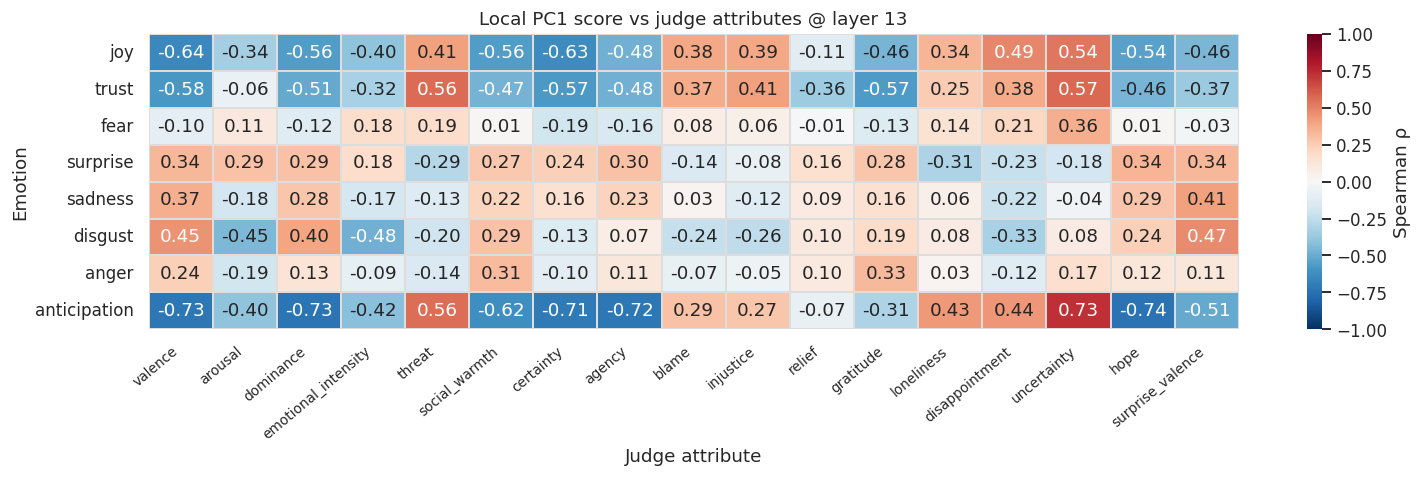

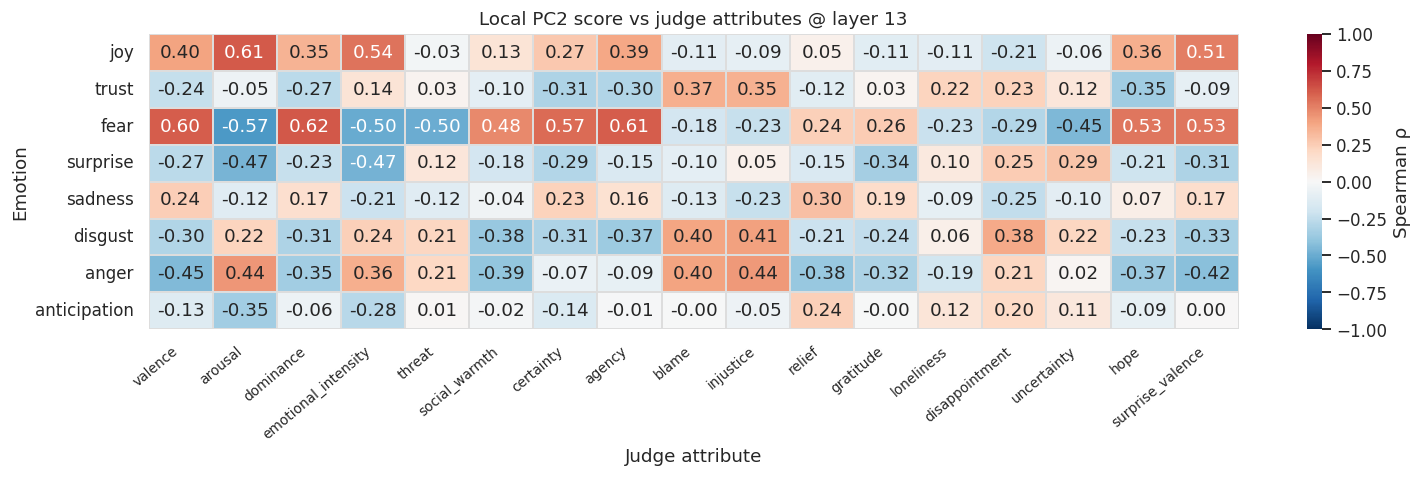

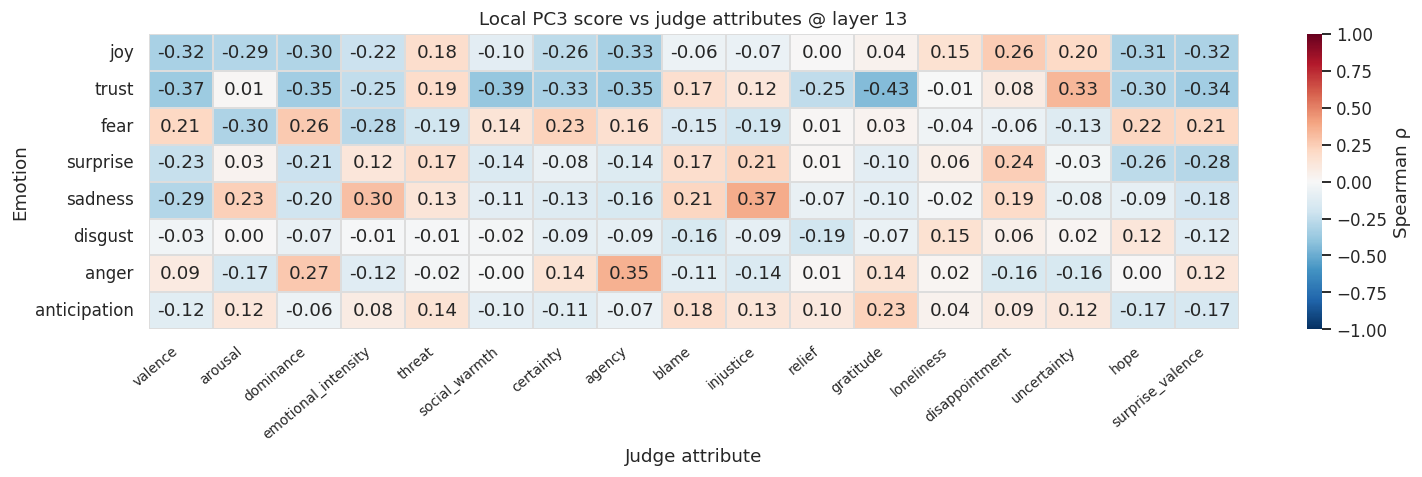

In [16]:
# ── Heatmap of |ρ| per emotion × local PC (columns = judge attributes) ────────
for local_pc_label in ['PC1', 'PC2', 'PC3']:
    sub = CORR_DF[CORR_DF['local_pc'] == local_pc_label].set_index('emotion')
    mat = sub[JUDGE_ATTRS].astype(float)

    fig, ax = plt.subplots(figsize=(14, 4.5))
    sns.heatmap(mat, annot=True, fmt='.2f', center=0,
                vmin=-1, vmax=1, cmap='RdBu_r', ax=ax,
                cbar_kws={'label': 'Spearman ρ'},
                linewidths=0.3, linecolor='#dddddd')
    ax.set_title(f'Local {local_pc_label} score vs judge attributes @ layer {STEER_LAYER}')
    ax.set_xlabel('Judge attribute'); ax.set_ylabel('Emotion')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha='right', fontsize=9)
    fig.tight_layout()
    fig.savefig(OUT_DIR / f'corr_local_{local_pc_label}_judge.png', dpi=140)
    plt.show()



---
## 6. Per-emotion interpretation summary

For each emotion × local PC, we identify:
- The **best-correlated** judge attribute (highest |ρ|) → semantic axis label.
- The sign of ρ → which pole is which.
- The global axis alignment (max |cos|).



In [17]:
interp_rows = []
for emo in EMOTION_ORDER:
    for k in range(K_LOCAL):
        pc_label = f'PC{k+1}'
        lp = LOCAL[emo]
        evr_k = float(lp['evr_k'][k])
        pr    = lp['pr']

        # best judge attribute
        row_corr = CORR_DF[(CORR_DF['emotion'] == emo) & (CORR_DF['local_pc'] == pc_label)]
        attr_vals = row_corr[JUDGE_ATTRS].iloc[0]
        abs_vals  = attr_vals.abs()
        best_attr = abs_vals.idxmax()
        best_rho  = float(attr_vals[best_attr])

        # global alignment
        row_align = ALIGN_DF[(ALIGN_DF['emotion'] == emo) & (ALIGN_DF['local_pc'] == pc_label)]
        best_global = row_align['best_match'].values[0]
        max_cos     = row_align['max_cos'].values[0]

        # axis label: positive pole ≈ high best_attr if rho>0 else low best_attr
        sign_str = '+' if best_rho > 0 else '−'
        axis_label = f'{sign_str}{best_attr}'

        interp_rows.append({
            'emotion':      emo,
            'local_pc':     pc_label,
            'EVR':          round(evr_k, 4),
            'PR':           round(pr, 2),
            'best_judge_attr':    best_attr,
            'spearman_rho':       round(best_rho, 3),
            'axis_label':         axis_label,
            'global_best_match':  best_global,
            'global_max_cos':     round(float(max_cos), 3),
        })

INTERP_DF = pd.DataFrame(interp_rows)
INTERP_DF.to_csv(OUT_DIR / 'local_pc_interpretation.csv', index=False)

print('=== Per-emotion local PC interpretation ===')
for emo in EMOTION_ORDER:
    print(f'\n{emo.upper()}')
    sub = INTERP_DF[INTERP_DF['emotion'] == emo][
        ['local_pc', 'EVR', 'best_judge_attr', 'spearman_rho', 'axis_label', 'global_best_match']
    ]
    display(sub.set_index('local_pc'))



=== Per-emotion local PC interpretation ===

JOY


,EVR,best_judge_attr,spearman_rho,axis_label,global_best_match
local_pc,,,,,
PC1,0.1414,valence,-0.644,−valence,gPC2
PC2,0.0478,arousal,0.611,+arousal,v_int
PC3,0.0382,agency,-0.330,−agency,gPC1



TRUST


,EVR,best_judge_attr,spearman_rho,axis_label,global_best_match
local_pc,,,,,
PC1,0.0967,valence,-0.581,−valence,gPC2
PC2,0.0460,blame,0.366,+blame,gPC1
PC3,0.0327,gratitude,-0.435,−gratitude,gPC4



FEAR


...

,EVR,best_judge_attr,spearman_rho,axis_label,global_best_match
local_pc,,,,,
PC1,0.0815,emotional_intensity,-0.477,−emotional_intensity,gPC2
PC2,0.0408,injustice,0.413,+injustice,v_int
PC3,0.0348,relief,-0.191,−relief,gPC4



ANGER


,EVR,best_judge_attr,spearman_rho,axis_label,global_best_match
local_pc,,,,,
PC1,0.0689,gratitude,0.327,+gratitude,gPC2
PC2,0.0484,valence,-0.445,−valence,gPC2
PC3,0.0356,agency,0.353,+agency,gPC2



ANTICIPATION


,EVR,best_judge_attr,spearman_rho,axis_label,global_best_match
local_pc,,,,,
PC1,0.0741,hope,-0.742,−hope,gPC3
PC2,0.0567,arousal,-0.351,−arousal,gPC2
PC3,0.0327,gratitude,0.232,+gratitude,gPC1


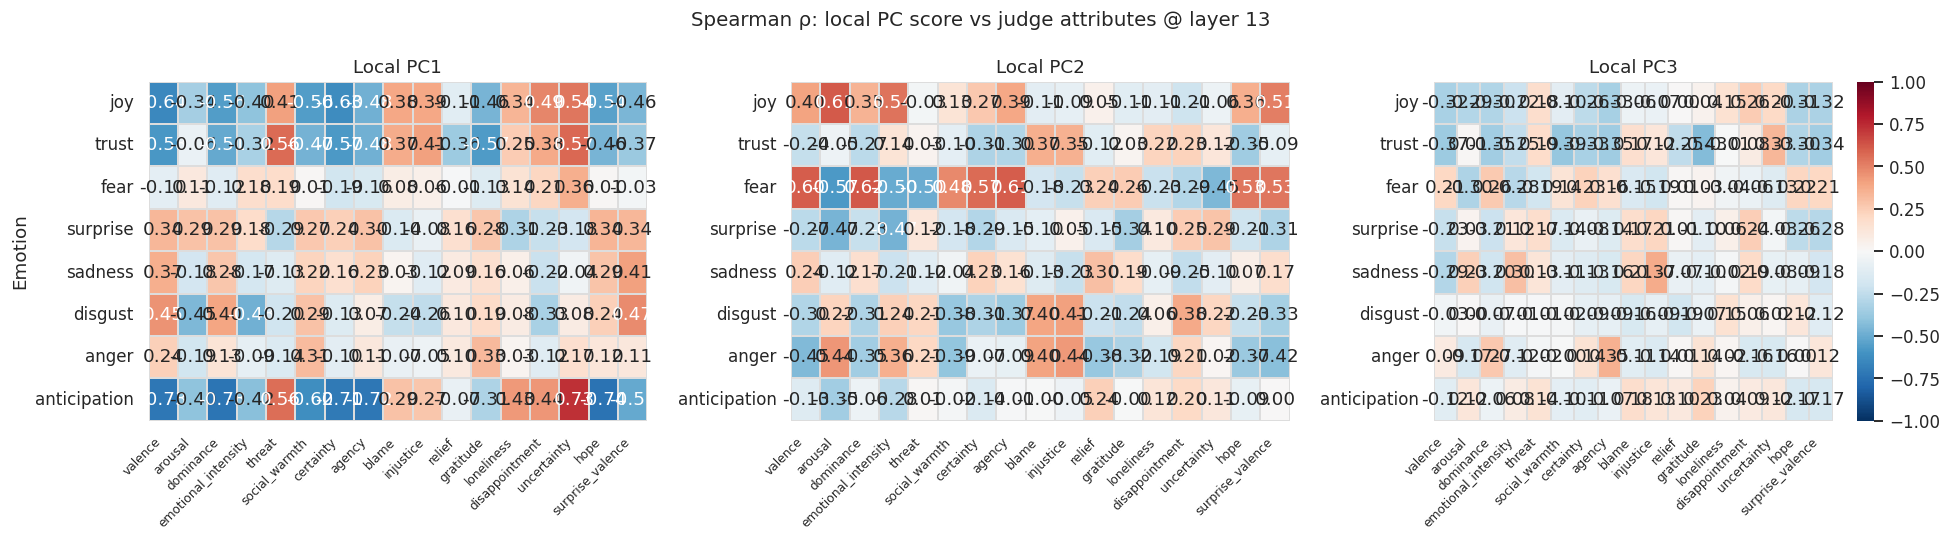

In [18]:
# ── Visual: top-2 judge attributes per local PC1 across emotions ──────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for k, ax in enumerate(axes):
    pc_label = f'PC{k+1}'
    sub = CORR_DF[CORR_DF['local_pc'] == pc_label].set_index('emotion')
    mat = sub[JUDGE_ATTRS].astype(float)
    mat = mat.reindex(EMOTION_ORDER)

    sns.heatmap(mat, annot=True, fmt='.2f', center=0,
                vmin=-1, vmax=1, cmap='RdBu_r', ax=ax,
                cbar=(k == 2),
                linewidths=0.3, linecolor='#dddddd')
    ax.set_title(f'Local {pc_label}', fontsize=12)
    ax.set_xlabel('')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)
    ax.set_ylabel('Emotion' if k == 0 else '')

fig.suptitle(f'Spearman ρ: local PC score vs judge attributes @ layer {STEER_LAYER}',
             fontsize=13)
fig.tight_layout()
fig.savefig(OUT_DIR / 'corr_all_pcs_overview.png', dpi=140)
plt.show()



---
## 7. Summary

Save all headline numerics to `summary.json`.



In [19]:
summary = {
    'layer': STEER_LAYER,
    'K_LOCAL': K_LOCAL,
    'judge_model': JUDGE_MODEL,
    'prompt_version': PROMPT_VERSION,
    'judge_sample_size': len(JUDGE_DF),
    'dry_run': DRY_RUN,
    'judge_attrs': JUDGE_ATTRS,

    # ── Local PCA ──────────────────────────────────────────────────────────
    'per_emotion': {
        emo: {
            'participation_ratio':   round(LOCAL[emo]['pr'], 3),
            'evr_k': [round(float(v), 4) for v in LOCAL[emo]['evr_k']],
            'pc1_intensity_spearman': round(
                float(rho_df.loc[emo, 'spearman_rho_pc1_int']), 4
            ),
            'local_pcs': {
                f'PC{k+1}': {
                    'evr':             round(float(LOCAL[emo]['evr_k'][k]), 4),
                    'best_judge_attr': str(
                        INTERP_DF[(INTERP_DF.emotion==emo) & (INTERP_DF.local_pc==f'PC{k+1}')]
                        ['best_judge_attr'].values[0]
                    ),
                    'spearman_rho':    round(float(
                        INTERP_DF[(INTERP_DF.emotion==emo) & (INTERP_DF.local_pc==f'PC{k+1}')]
                        ['spearman_rho'].values[0]
                    ), 3),
                    'global_best_match': str(
                        INTERP_DF[(INTERP_DF.emotion==emo) & (INTERP_DF.local_pc==f'PC{k+1}')]
                        ['global_best_match'].values[0]
                    ),
                    'global_max_cos': round(float(
                        INTERP_DF[(INTERP_DF.emotion==emo) & (INTERP_DF.local_pc==f'PC{k+1}')]
                        ['global_max_cos'].values[0]
                    ), 3),
                }
                for k in range(K_LOCAL)
            },
        }
        for emo in EMOTION_ORDER
    },

    'config': {
        'steer_layer':  STEER_LAYER,
        'K_LOCAL':      K_LOCAL,
        'max_sources':  MAX_SOURCES,
        'n_sources_used': N_SUB,
        'n_ex_judge':   N_EX_JUDGE,
        'strat_per_cell': STRAT_PER_CELL,
    },
}

out_path = OUT_DIR / 'summary.json'
with open(out_path, 'w') as f:
    json.dump(summary, f, indent=2)
print('Wrote', out_path)
print('\nOutput files in', OUT_DIR, ':')
for p in sorted(OUT_DIR.iterdir()):
    print(f'  {p.name}')



Wrote /home/maplesugano/proj/EmotionEngine_v2/analysis/emotion_intensity/emotion_internal_structure/summary.json

Output files in /home/maplesugano/proj/EmotionEngine_v2/analysis/emotion_intensity/emotion_internal_structure :
  alignment_local_PC1.png
  alignment_local_PC2.png
  alignment_local_PC3.png
  corr_all_pcs_overview.png
  corr_local_PC1_judge.png
  corr_local_PC2_judge.png
  corr_local_PC3_judge.png
  judge_cache
  judge_sample.parquet
  judge_scores.parquet
  local_global_alignment.csv
  local_pc1_intensity_boxplot.png
  local_pc1_intensity_spearman.csv
  local_pc_extremes.csv
  local_pc_interpretation.csv
  local_pc_judge_spearman.csv
  local_pca_evr.csv
  local_pca_evr_pr.png
  summary.json
